# Significant blocks & genes per variant class + SNP / indel / SV overlap

clq0.9 **tiling** blocks, **raw LFMM** p (gen9, MAF>0.05). A block is *significant* for a
class if its lead (min-p) record of that class clears the per-class Bonferroni bar
(0.05 / n_records) on **>=1** of the 20 climate axes (bio1-19 + pc1). Genes = protein-coding
genes overlapping a significant block (TAIR10).

- **Table:** significant / tested blocks and gene counts per class (snp · smallindel · sv ·
  pooled non-SNP), with percentages of the tested blocks and of all 27,206 genes.
- **Venn (blocks):** do the three classes mark the **same blocks**? Circles = snp / smallindel
  / sv significant-block sets; overlap = a block significant in >1 class.
- **Venn (genes):** same, on the gene sets.

Raw, uncalibrated p (inflation acknowledged, kept deliberately).

In [1]:
import os, sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn3_circles
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import lib
WZAIN = f"{lib.GEA}/phase1_replication/results/multiaxis/wza_in_clq09_tile"
OUTDIR = f"{lib.GEA}/phase1_replication/results/multiaxis"
AXES = [f"bio{i}" for i in range(1, 20)] + ["pc1"]
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

# block spans (tiling) -> genes overlapping each block
SP = {}
for ci in range(1, 6):
    g = pd.read_csv(f"{lib.CLQ_BLOCKS_DIR}/chr{ci}_clq0.9_blocks_clq0.9.tsv", sep="\t").sort_values("start_pos").reset_index(drop=True)
    ends = g.end_pos.to_numpy(np.int64)
    for i in range(len(g)):
        lo = 1 if i == 0 else int(ends[i-1]) + 1
        hi = int(ends[i]) if i < len(g)-1 else 10**9
        SP[f"Chr{ci}_{i}"] = (f"Chr{ci}", lo, hi)
GENES = lib.load_genes(); N_GENES_TOTAL = len(GENES)
def genes_on(b):
    if b not in SP: return []
    ch, lo, hi = SP[b]
    gc = GENES[(GENES.chrom == ch) & (GENES.end >= lo) & (GENES.start <= hi)]
    return list(gc.gene)

def load(cls, a):
    d = pd.read_csv(f"{WZAIN}/lfmm_{cls}_gen9_{a}.csv"); d = d[d.MAF > 0.05].copy()
    d["nlp"] = -np.log10(d.pval.clip(lower=1e-300)); return d
def leads(d):
    d = d[d.block.notna() & (d.block != "")]
    return d.loc[d.groupby("block")["nlp"].idxmax()]
print("total tiling blocks:", len(SP), "| total protein-coding genes:", N_GENES_TOTAL)

total tiling blocks: 58376 | total protein-coding genes: 27206


In [2]:
# --- per class: tested-block set, significant-block set, gene set (slow: loads 60+ CSVs) ---
SIG = {}
for cls in ["snp", "smallindel", "sv", "nonsnp"]:
    tested = set(load(cls, "bio1").block.dropna().unique())     # membership axis-invariant
    sig = set()
    for a in AXES:
        c = load(cls, a); bc = -np.log10(0.05 / len(c))
        lc = leads(c)
        sig.update(lc.loc[lc.nlp > bc, "block"].tolist())
    genes = set()
    for b in sig: genes.update(genes_on(b))
    SIG[cls] = dict(tested=tested, blocks=sig, genes=genes)
    print(f"{cls:>11}: tested {len(tested):6d} | sig blocks {len(sig):5d} | genes {len(genes):5d}")

        snp: tested  56846 | sig blocks  1008 | genes  1883


 smallindel: tested  41731 | sig blocks   966 | genes  1860


         sv: tested   4520 | sig blocks   209 | genes   447


     nonsnp: tested  41908 | sig blocks   984 | genes  1881


In [3]:
# --- summary table ---
rows = []
for cls in ["snp", "smallindel", "sv", "nonsnp"]:
    d = SIG[cls]
    rows.append(dict(
        variant_class=cls,
        tested_blocks=len(d["tested"]),
        sig_blocks=len(d["blocks"]),
        pct_blocks=round(100*len(d["blocks"])/len(d["tested"]), 2),
        genes=len(d["genes"]),
        pct_of_all_genes=round(100*len(d["genes"])/N_GENES_TOTAL, 2),
    ))
TBL = pd.DataFrame(rows)
TBL.to_csv(f"{OUTDIR}/significance_summary_table.csv", index=False)
print("total tiling blocks: {}   |   total protein-coding genes: {}".format(len(SP), N_GENES_TOTAL))
display(TBL)

total tiling blocks: 58376   |   total protein-coding genes: 27206


,variant_class,tested_blocks,sig_blocks,pct_blocks,genes,pct_of_all_genes
0,snp,56846,1008,1.77,1883,6.92
1,smallindel,41731,966,2.31,1860,6.84
2,sv,4520,209,4.62,447,1.64
3,nonsnp,41908,984,2.35,1881,6.91


## Venn — do SNP / indel / SV mark the same **blocks**?

Circles are the significant-block sets for the three primary classes. Overlap = a block that
is independently climate-significant in more than one class. Because a block can only enter a
class' circle if it carries a testable record of that class, the maximum possible 3-way overlap
is the number of blocks testable in all three (annotated below the diagram).

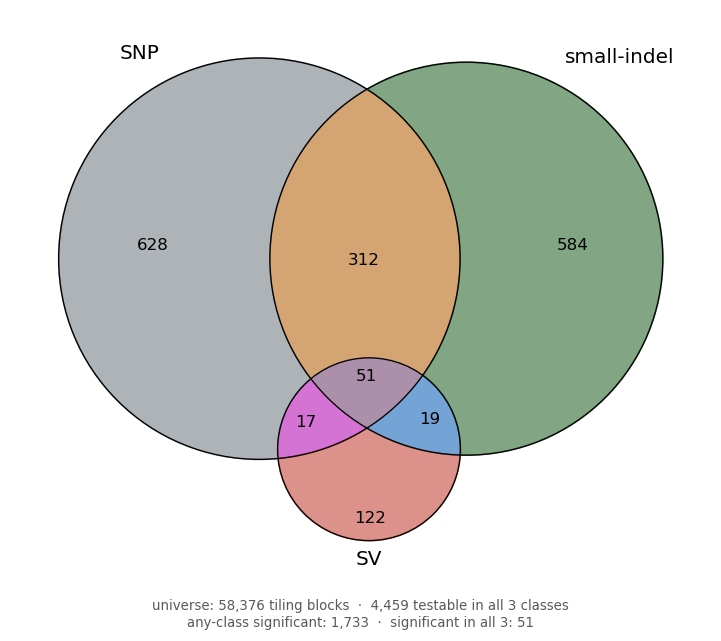

block overlaps:
  SNP-only 628 | indel-only 584 | SV-only 122
  SNP&indel 312 | SNP&SV 17 | indel&SV 19 | all3 51


In [4]:
CLSCOL = {"snp": "#6C757D", "smallindel": "#1B5E20", "sv": "#C0392B"}

def venn_three(sets, labels, colors, ax):
    v = venn3([sets[0], sets[1], sets[2]], set_labels=labels, ax=ax)
    for i, pid in enumerate(["100", "010", "001"]):
        p = v.get_patch_by_id(pid)
        if p: p.set_color(colors[i]); p.set_alpha(0.55)
    for pid in ["110", "101", "011", "111"]:
        p = v.get_patch_by_id(pid)
        if p: p.set_alpha(0.55)
    venn3_circles([sets[0], sets[1], sets[2]], lw=0.8, ax=ax)
    return v

A, B, Cc = SIG["snp"]["blocks"], SIG["smallindel"]["blocks"], SIG["sv"]["blocks"]
fig, ax = plt.subplots(figsize=(7.5, 6.5))
venn_three([A, B, Cc], ("SNP", "small-indel", "SV"),
           [CLSCOL["snp"], CLSCOL["smallindel"], CLSCOL["sv"]], ax)
co_test = SIG["snp"]["tested"] & SIG["smallindel"]["tested"] & SIG["sv"]["tested"]
ax.annotate(f"universe: {len(SP):,} tiling blocks  ·  {len(co_test):,} testable in all 3 classes\n"
            f"any-class significant: {len(A|B|Cc):,}  ·  significant in all 3: {len(A&B&Cc):,}",
            xy=(0.5, -0.02), xycoords="axes fraction", ha="center", va="top", fontsize=8, color="0.35")
plt.show()
print("block overlaps:")
print(f"  SNP-only {len(A-B-Cc)} | indel-only {len(B-A-Cc)} | SV-only {len(Cc-A-B)}")
print(f"  SNP&indel {len((A&B)-Cc)} | SNP&SV {len((A&Cc)-B)} | indel&SV {len((B&Cc)-A)} | all3 {len(A&B&Cc)}")

## Venn — same three classes, on **genes**

Genes overlapping the significant blocks of each class. (Overlap here is inflated relative to
the block Venn: one shared multigene block puts all its genes into the intersection, so read the
block Venn as the primary result and this as the gene-level consequence.)

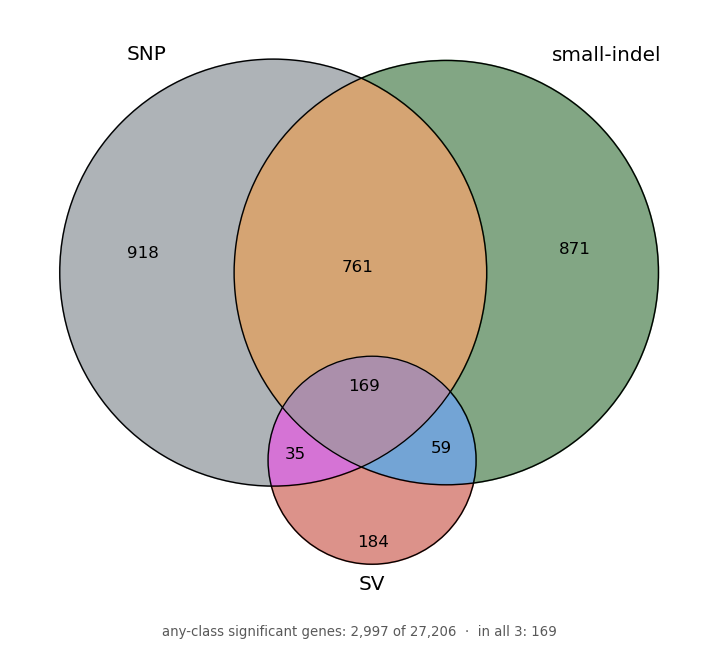

gene overlaps:
  SNP-only 918 | indel-only 871 | SV-only 184
  SNP&indel 761 | SNP&SV 35 | indel&SV 59 | all3 169


In [5]:
Ag, Bg, Cg = SIG["snp"]["genes"], SIG["smallindel"]["genes"], SIG["sv"]["genes"]
fig, ax = plt.subplots(figsize=(7.5, 6.5))
venn_three([Ag, Bg, Cg], ("SNP", "small-indel", "SV"),
           [CLSCOL["snp"], CLSCOL["smallindel"], CLSCOL["sv"]], ax)
ax.annotate(f"any-class significant genes: {len(Ag|Bg|Cg):,} of {N_GENES_TOTAL:,}  ·  in all 3: {len(Ag&Bg&Cg):,}",
            xy=(0.5, -0.02), xycoords="axes fraction", ha="center", va="top", fontsize=8, color="0.35")
plt.show()
print("gene overlaps:")
print(f"  SNP-only {len(Ag-Bg-Cg)} | indel-only {len(Bg-Ag-Cg)} | SV-only {len(Cg-Ag-Bg)}")
print(f"  SNP&indel {len((Ag&Bg)-Cg)} | SNP&SV {len((Ag&Cg)-Bg)} | indel&SV {len((Bg&Cg)-Ag)} | all3 {len(Ag&Bg&Cg)}")